#**Medical Image Classification Using Convolutional Neural Networks (CNNs)**



# **1- Environment Setup**

### **Library Installation**

In [ ]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [ ]:
!pip install -U scikit-learn==1.5.2

In [ ]:
!pip install scikeras==0.13.0 --upgrade

In [ ]:
!pip install opendatasets

### **GPU Cheack**
 Cheack GPU if it's available or not, if not Activative it

In [ ]:
import torch

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Is Available: {torch.cuda.is_available()}")
else:
    print("GPU is not available.")


GPU Name: NVIDIA A100-SXM4-80GB
GPU Is Available: True


In [ ]:
def num_gpus():
    """Get the number of available GPUs."""
    return torch.cuda.device_count()

num_gpus()

1

#**2- HAM10000 DataSet**

### **Dowmload dataset**
Dowmload Skin Cancer MNIST: HAM10000 Dataset from Kaggle directly using API Token

In [ ]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: madaweealabdulkreem
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000


100%|██████████| 5.20G/5.20G [00:12<00:00, 443MB/s]


In [ ]:
import os
data_dir = "./skin-cancer-mnist-ham10000"
os.listdir(data_dir)

['hmnist_28_28_L.csv',
 'hmnist_8_8_L.csv',
 'hmnist_28_28_RGB.csv',
 'HAM10000_images_part_2',
 'HAM10000_images_part_1',
 'ham10000_images_part_1',
 'ham10000_images_part_2',
 'HAM10000_metadata.csv',
 'hmnist_8_8_RGB.csv']

In [ ]:
import pandas as pd
import numpy as np
np.random.seed(42)
metadata_path = os.path.join(data_dir, "HAM10000_metadata.csv")
ham_dataset = pd.read_csv(metadata_path)

# **3- Data Exploration and Preprocessing**
Display dataset (metadata.csv) to understand its structure and features, The HAM10000 dataset contain 10015 row and 7 columns, it's contain 7 catagories:

-	nv: Melanocytic nevi
-	mel: Melanoma
-	bkl: Benign keratosis-like lesions
-	bcc: Basal cell carcinoma
-	acliec: Actinic keratoses
-	vas: Vascular lesions
-	df: Dermatofibroma

I read "The HAM10000 dataset: a large collection of multi-source dermatoscopic images  of common pigmented skin lesions" to understand the dataset and its classes.

In [ ]:
ham_dataset

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face


note that in the first two row we have the same (lesion id) but a diffrent image id

In [ ]:
classes = np.unique(ham_dataset['dx'])
nClasses = len(classes)

print("Number of classes:", nClasses)
print(classes)

Number of classes: 7
['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


In [ ]:
# Checking for null and other info
ham_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


#### **Map each imge_id with its image file to make it easier in the next operations.**

In [ ]:
from glob import glob
all_images = glob(os.path.join(data_dir, "HAM10000_images_part_*", "*.jpg"))
image_path = {os.path.splitext(os.path.basename(x))[0]: x for x in all_images}
print("img num::", len(all_images))

img num:: 10015


#### **Resizing images (64*64)**


In [ ]:
from PIL import Image
#Define the path and add as a new column
ham_dataset['path'] = ham_dataset['image_id'].map(image_path.get)
#Use the path to read images.
ham_dataset['image'] = ham_dataset['path'].map(lambda x: np.asarray(Image.open(x).resize((64,64))))

add path and image into the coulmns

In [ ]:
ham_dataset

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,image
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,./skin-cancer-mnist-ham10000/HAM10000_images_p...,"[[[191, 152, 194], [191, 153, 195], [192, 149,..."
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,./skin-cancer-mnist-ham10000/HAM10000_images_p...,"[[[23, 13, 23], [25, 14, 28], [37, 24, 46], [6..."
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,./skin-cancer-mnist-ham10000/HAM10000_images_p...,"[[[186, 129, 140], [192, 136, 151], [198, 143,..."
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,./skin-cancer-mnist-ham10000/HAM10000_images_p...,"[[[24, 11, 19], [36, 20, 30], [64, 38, 50], [9..."
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,./skin-cancer-mnist-ham10000/HAM10000_images_p...,"[[[139, 95, 118], [158, 114, 138], [178, 133, ..."
...,...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,./skin-cancer-mnist-ham10000/HAM10000_images_p...,"[[[161, 143, 155], [159, 142, 154], [154, 137,..."
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,./skin-cancer-mnist-ham10000/HAM10000_images_p...,"[[[6, 7, 4], [7, 8, 5], [8, 8, 6], [29, 27, 25..."
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,./skin-cancer-mnist-ham10000/HAM10000_images_p...,"[[[117, 108, 110], [139, 127, 126], [134, 118,..."
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,./skin-cancer-mnist-ham10000/HAM10000_images_p...,"[[[159, 123, 145], [156, 116, 134], [161, 130,..."


#### **Cheack for missing data**


In [ ]:
print("Dataset shape:", ham_dataset.shape)

print("\nMissing values:")
print(ham_dataset.isnull().sum())

Dataset shape: (10015, 9)

Missing values:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
path             0
image            0
dtype: int64


age has null values so wee need to get rid of them or we can ignore it

In [ ]:
#drop rows with missing values and duplicates
ham_dataset = ham_dataset.dropna()
ham_dataset = ham_dataset.drop_duplicates(subset='image_id')

In [ ]:
print("\nMissing values:")
print(ham_dataset.isnull().sum())


Missing values:
lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
path            0
image           0
dtype: int64


#### **Data Visualization**

Visualize the categories (dx) balance

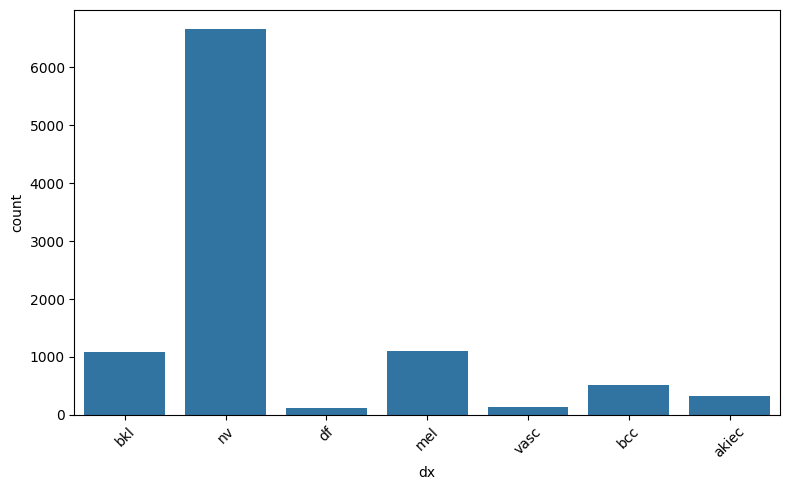

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='dx', data=ham_dataset)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We can see the data is unbalanced

In [ ]:
#Check how many in each one
ham_dataset['dx'].value_counts()

,count
dx,
nv,6660
mel,1111
bkl,1089
bcc,514
akiec,327
vasc,142
df,115


as we can see the classes are imbalanced, **nv** contain **6660** while **df** contain **115** and that's a big difference that will effect on the results

#### **Display some of the data**

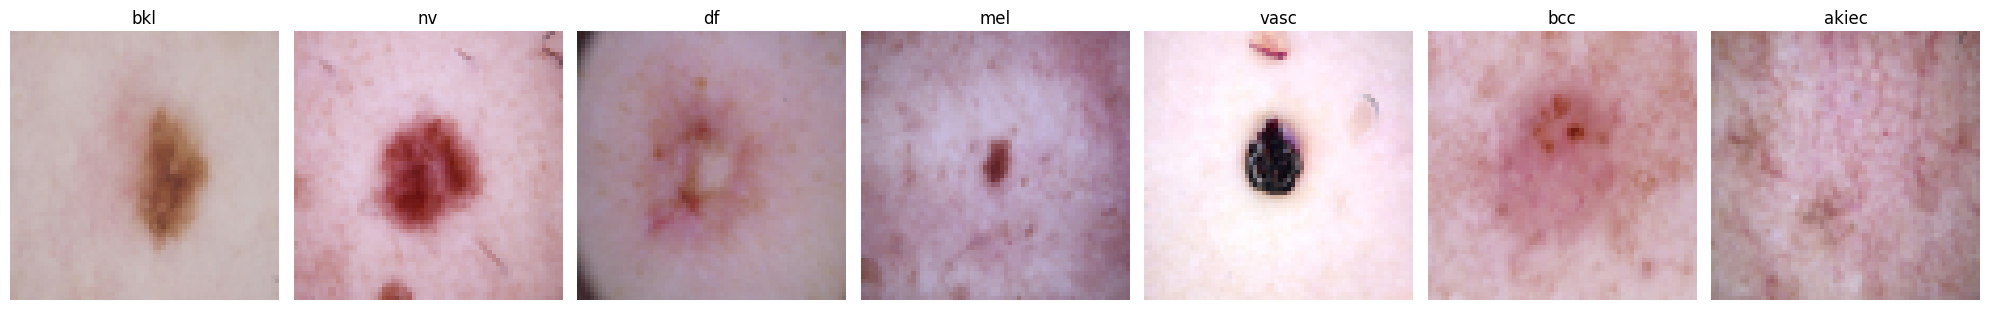

In [ ]:
n_samples = 1
categories = ham_dataset['dx'].unique()

fig, axes = plt.subplots(1, len(categories), figsize=(20, 4))

for ax, category in zip(axes, categories):
    sample = ham_dataset[ham_dataset['dx'] == category].sample(1, random_state=1234)
    img = sample.iloc[0]['image']

    ax.imshow(img)
    ax.set_title(category)
    ax.axis('off')

plt.tight_layout()
plt.show()

# **4-Split of Data**

Check for Duplicate Lesions

In [ ]:
# get number of non-unique lesion_id's
def check_duplicates(df, col):
    unique_list = df.lesion_id.unique().tolist()
    num_duplicates = len(df) - len(unique_list)
    return num_duplicates

num_duplicates = check_duplicates(ham_dataset, 'lesion_id')
print(f'Duplicate lesion_ids: {num_duplicates} out of {len(ham_dataset)}')

Duplicate lesion_ids: 2540 out of 9958


Split the Dataset based on lesion id

In [ ]:
from sklearn.model_selection import train_test_split

unique_lesions = ham_dataset['lesion_id'].unique()

# Splite the dataset based on 'lesion_id' intp train - test - validation 70:15:15
train_lesions, temp_lesions = train_test_split(unique_lesions, test_size=0.30, random_state=42)
val_lesions, test_lesions = train_test_split(temp_lesions, test_size=0.50, random_state=42)

#DataFrames
train_df = ham_dataset[ham_dataset['lesion_id'].isin(train_lesions)]
val_df   = ham_dataset[ham_dataset['lesion_id'].isin(val_lesions)]
test_df  = ham_dataset[ham_dataset['lesion_id'].isin(test_lesions)]

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 6957
Val: 1493
Test: 1508


Check for overlapping lesions between train, validation, and test sets


In [ ]:
overlap_train_val = set(train_df['lesion_id']).intersection(set(val_df['lesion_id']))
overlap_train_test = set(train_df['lesion_id']).intersection(set(test_df['lesion_id']))
overlap_val_test = set(val_df['lesion_id']).intersection(set(test_df['lesion_id']))

print("Overlap train-val:", len(overlap_train_val))
print("Overlap train-test:", len(overlap_train_test))
print("Overlap val-test:", len(overlap_val_test))

Overlap train-val: 0
Overlap train-test: 0
Overlap val-test: 0


Save train/val/test splits to CSV and reload them


In [ ]:
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

train_df = pd.read_csv("train_split.csv")
val_df = pd.read_csv("val_split.csv")
test_df = pd.read_csv("test_split.csv")

In [ ]:
train_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,image
0,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[186 129 140]\n [192 136 151]\n [198 143 1...
1,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[24 11 19]\n [36 20 30]\n [64 38 50]\n .....
2,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[139 95 118]\n [158 114 138]\n [178 133 1...
3,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[ 5 0 1]\n [ 9 1 4]\n [12 3 7]\n .....
4,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[192 146 131]\n [194 145 137]\n [194 146 1...
...,...,...,...,...,...,...,...,...,...
6952,HAM_0004034,ISIC_0024948,akiec,histo,55.0,female,face,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[202 150 150]\n [203 155 155]\n [205 160 1...
6953,HAM_0001565,ISIC_0028619,akiec,histo,60.0,female,face,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[30 15 19]\n [26 12 17]\n [25 10 19]\n .....
6954,HAM_0001576,ISIC_0033705,akiec,histo,60.0,male,face,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[193 154 173]\n [173 127 140]\n [170 130 1...
6955,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[159 123 145]\n [156 116 134]\n [161 130 1...


Cheack for data imbalnce again for the train to apply data agumentation

In [ ]:
train_df['dx'].value_counts()

,count
dx,
nv,4719
mel,776
bkl,724
bcc,338
akiec,229
vasc,86
df,85


In [ ]:
val_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,image
0,HAM_0006574,ISIC_0030698,bkl,histo,40.0,male,back,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[149 137 160]\n [151 139 165]\n [152 139 1...
1,HAM_0006574,ISIC_0025567,bkl,histo,40.0,male,back,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[188 169 199]\n [188 170 205]\n [187 169 2...
2,HAM_0005772,ISIC_0031159,bkl,histo,60.0,female,face,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[180 144 163]\n [180 136 153]\n [180 141 1...
3,HAM_0005772,ISIC_0031017,bkl,histo,60.0,female,face,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[171 139 156]\n [167 136 153]\n [172 143 1...
4,HAM_0005388,ISIC_0027815,bkl,histo,80.0,male,chest,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[10 6 12]\n [27 17 28]\n [39 27 40]\n .....
...,...,...,...,...,...,...,...,...,...
1488,HAM_0006220,ISIC_0028517,akiec,histo,60.0,male,upper extremity,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[161 115 134]\n [173 123 139]\n [183 133 1...
1489,HAM_0001152,ISIC_0030133,akiec,histo,65.0,male,face,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[191 147 158]\n [187 137 149]\n [188 135 1...
1490,HAM_0004282,ISIC_0033811,akiec,histo,65.0,female,face,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[111 80 85]\n [112 81 85]\n [113 82 ...
1491,HAM_0004282,ISIC_0033358,akiec,histo,65.0,female,face,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[180 131 151]\n [182 136 154]\n [186 142 1...


In [ ]:
test_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,image
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[191 152 194]\n [191 153 195]\n [192 149 1...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[23 13 23]\n [25 14 28]\n [37 24 46]\n .....
2,HAM_0007207,ISIC_0031326,bkl,histo,65.0,male,back,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[193 156 177]\n [199 158 180]\n [200 162 1...
3,HAM_0002521,ISIC_0027828,bkl,histo,40.0,male,upper extremity,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[188 177 216]\n [190 175 216]\n [191 176 2...
4,HAM_0002521,ISIC_0029291,bkl,histo,40.0,male,upper extremity,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[ 45 34 44]\n [ 75 61 76]\n [104 88 1...
...,...,...,...,...,...,...,...,...,...
1503,HAM_0006180,ISIC_0028990,akiec,histo,70.0,male,upper extremity,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[ 55 28 50]\n [ 86 55 83]\n [133 94 1...
1504,HAM_0005705,ISIC_0031430,akiec,histo,75.0,female,lower extremity,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[165 157 158]\n [165 157 157]\n [164 155 1...
1505,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[161 143 155]\n [159 142 154]\n [154 137 1...
1506,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,./skin-cancer-mnist-ham10000/HAM10000_images_p...,[[[ 6 7 4]\n [ 7 8 5]\n [ 8 8 ...


#### **Normalization**
Load, resize, normalize images and handle errors by adding a blank image if loading fails


In [ ]:
from tqdm import tqdm

def load_normalize_images(df, target_size=(64, 64)):
    images = []
    for path in tqdm(df['path']):
        try:
            # Load image
            img = Image.open(path)
            # Resize if needed
            if img.size != target_size:
                img = img.resize(target_size)
            # Convert to array and normalize to [0, 1]
            img_array = np.array(img).astype('float32') / 255.0
            # Ensure 3 channels (convert RGBA to RGB if needed)
            if len(img_array.shape) == 3 and img_array.shape[-1] == 4:
                img_array = img_array[:, :, :3]
            images.append(img_array)
        except Exception as e:
            print(f"Error loading image {path}: {e}")
            # Add a normalized blank image
            images.append(np.zeros((*target_size, 3), dtype='float32'))

    return np.array(images)

# Load and normalize images
X_train = load_normalize_images(train_df)
X_val = load_normalize_images(val_df)
X_test = load_normalize_images(test_df)

print(f"shape: {X_train.shape}")
print(f"after normalization: [{X_train.min():.3f}, {X_train.max():.3f}]")

100%|██████████| 1508/1508 [00:10<00:00, 140.79it/s]


shape: (6957, 64, 64, 3)
after normalization: [0.000, 1.000]


#### **Encoding Class Labels**
Encode class labels (dx) as integers and convert to one-hot vectors for model training


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(train_df['dx'])
y_val_encoded = label_encoder.transform(val_df['dx'])
y_test_encoded = label_encoder.transform(test_df['dx'])

# Convert to categorical (one-hot encoding)
y_train = to_categorical(y_train_encoded, num_classes=nClasses)
y_val = to_categorical(y_val_encoded, num_classes=nClasses)
y_test = to_categorical(y_test_encoded, num_classes=nClasses)

In [ ]:
X_train

array([[[[0.7294118 , 0.5058824 , 0.54901963],
         [0.7529412 , 0.53333336, 0.5921569 ],
         [0.7764706 , 0.56078434, 0.6156863 ],
         ...,
         [0.60784316, 0.4392157 , 0.50980395],
         [0.56078434, 0.4       , 0.46666667],
         [0.5137255 , 0.36078432, 0.42352942]],

        [[0.73333335, 0.52156866, 0.5803922 ],
         [0.7529412 , 0.54509807, 0.6117647 ],
         [0.78039217, 0.5764706 , 0.6431373 ],
         ...,
         [0.6313726 , 0.4627451 , 0.5372549 ],
         [0.58431375, 0.41568628, 0.48235294],
         [0.5372549 , 0.37254903, 0.43137255]],

        [[0.7490196 , 0.5372549 , 0.6039216 ],
         [0.78039217, 0.5803922 , 0.64705884],
         [0.79607844, 0.6039216 , 0.67058825],
         ...,
         [0.6509804 , 0.48235294, 0.5568628 ],
         [0.60784316, 0.4392157 , 0.50980395],
         [0.5647059 , 0.4       , 0.45882353]],

        ...,

        [[0.7607843 , 0.54509807, 0.6       ],
         [0.75686276, 0.5137255 , 0.57254905]

In [ ]:
y_train

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [ ]:
# Verify the normalization worked correctly
print(f"X_train shape: {X_train.shape}") # (num_samples, 64, 64, 3)
print(f"X_train dtype: {X_train.dtype}")
print(f"X_train range: [{X_train.min():.3f}, {X_train.max():.3f}]")

print(y_train.shape)  # (num_samples, nClasses)


X_train shape: (6957, 64, 64, 3)
X_train dtype: float32
X_train range: [0.000, 1.000]
(6957, 7)


#### **Data Agumentaion**
To balance training set, increase samples per class to target_count using ImageDataGenerator to all class except (nv)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
from tqdm import tqdm

# add 2000 to each class
target_count = 2000
#Data Agumentation
train_datagen = ImageDataGenerator(
    rotation_range=15,     # rotate ±15°
    width_shift_range=0.1, # shift horizontally ±10%
    height_shift_range=0.1,# shift vertically ±10%
    horizontal_flip=True,  # flip horizontally
    vertical_flip=True,    # flip vertically
    zoom_range=0.1,        # zoom ±10%
    shear_range=0.1,       # shear ±10%
    fill_mode='nearest'    # fill empty pixels with nearest
)

augmented_images = []
augmented_labels = []

# Apply in all class except ( nv )
for cls in train_df['dx'].unique():
    cls_indices = train_df[train_df['dx'] == cls].index
    X_cls = X_train[cls_indices]
    y_cls = y_train[cls_indices]

    n_samples = X_cls.shape[0]

    if n_samples >= target_count:
        # don't include nv
        X_final = X_cls
        y_final = y_cls
    else:
        n_needed = target_count - n_samples
        aug_iter = train_datagen.flow(X_cls, y_cls, batch_size=1, shuffle=True)

        X_aug, y_aug = [], []

        for _ in tqdm(range(n_needed)):
            X_batch, y_batch = next(aug_iter)
            X_aug.append(X_batch[0])
            y_aug.append(y_batch[0])

        X_final = np.concatenate([X_cls, np.array(X_aug)], axis=0)
        y_final = np.concatenate([y_cls, np.array(y_aug)], axis=0)

    augmented_images.append(X_final)
    augmented_labels.append(y_final)

# marge them
X_train_final = np.concatenate(augmented_images, axis=0)
y_train_final = np.concatenate(augmented_labels, axis=0)

print(f"\Training set shape: {X_train_final.shape}, {y_train_final.shape}")


y_labels = np.argmax(y_train_final, axis=1)
class_names = label_encoder.inverse_transform(y_labels)
class_distribution = pd.Series(class_names).value_counts()

print("\nafter augmentation:")
print(class_distribution)

<>:56: SyntaxWarning: invalid escape sequence '\T'
<>:56: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipython-input-3351504187.py:56: SyntaxWarning: invalid escape sequence '\T'
  print(f"\Training set shape: {X_train_final.shape}, {y_train_final.shape}")
100%|██████████| 1771/1771 [00:01<00:00, 1003.77it/s]


\Training set shape: (16719, 64, 64, 3), (16719, 7)

after augmentation:
nv       4719
bkl      2000
df       2000
mel      2000
vasc     2000
bcc      2000
akiec    2000
Name: count, dtype: int64


In [ ]:
X_train_final.shape
y_train_final.shape

(16719, 7)

# **5- Model architecture**

## Here is the custom CNN architectue I used

- **6 Conv layers** (32/64 filters, 3x3 & 5x5, ReLU) tried tanh but the relu was better
- **BatchNorm** and **Dropout**(0.25) tried two value 0.25 and 0.5 to avoid overfitting
- **Pooling** i tried bot MaxPooling and avgpooling the max was better
- **Flatten** :Dense(300,100, ReLU) + Dropout
- **Output** Dense(num_classes, softmax)
- **Optimizer**: AdamW also here tried Adam, SGD and AdamW
- **Loss**: categorical_crossentropy
- **Metric**: accuracy



In [ ]:
# From A Convolutional Neural Network Approach for Skin Lesion Classification Using Imbalanced Dataset with Image Augmentation
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,AveragePooling2D
from tensorflow.keras.layers import Activation
from tensorflow.keras.optimizers import AdamW


# Input size (64*64)
def create_model(learning_rate=1e-4,weight_decay=1e-5, input_shape=(64, 64, 3), num_classes=7):
    model = Sequential()

    #Convolutional layer 1 (32*32) - Filter size (3*3) - Activation Function (Relu)
    model.add(Conv2D(32, (3, 3), padding="same", activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))
    model.add(MaxPooling2D(2, 2))

    #Convolutional layer 2 (32*32) - Filter size (3*3) - Activation Function (Relu) - Dropout to avoid the overfitting
    model.add(Conv2D(32, (3, 3), padding="same",activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))
    model.add(MaxPooling2D(2, 2))

    #Convolutional layer 3 (32*32) - Filter size (5*5) - Activation Function (Relu) - Dropout to avoid the overfitting
    model.add(Conv2D(32, (5, 5), padding="same", activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    #Convolutional layer 4 (64*64) - Filter size (3*3) - Activation Function (Relu) - Dropout to avoid the overfitting
    model.add(Conv2D(64, (3, 3), padding="same", activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))
    model.add(MaxPooling2D(2, 2))

    #Convolutional layer 5 (64*64) - Filter size (3*3) - Activation Function (Relu) - Dropout to avoid the overfitting
    model.add(Conv2D(64, (3, 3), padding="same", activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    #Convolutional layer 6 (64*64) - Filter size (5*5) - Activation Function (Relu)
    model.add(Conv2D(64, (5, 5), padding="same", activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))


    #Flatten the input
    model.add(Flatten())

    #Fully connected layers
    model.add(Dense(300, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dropout(0.25))
    model.add(Dense(num_classes, activation='softmax')) #output

    #tried both Adam and AdamW and AdamW was better
    optimizer = AdamW(learning_rate=learning_rate, weight_decay=weight_decay)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# **6-Hyper-parameters Tuning with K-Folds** - RUN-ONES
- K-Folds: Use 3-fold cross-validation (KFold) to evaluate different hyper-parameter combinations, i used 5 too but it's get hevey on my laptop

- GridSearchCV tests batch_size, epochs, and learning_rate to find the best configuration.

- ModelCheckpoint saves the model

- EarlyStopping stops training if val_loss does not improve for 10 epochs and restores best weights.

- After fitting, print the best score and parameters along with mean/std for each combination.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import KFold
# Define the crossvalidation process to be used inside cross_val_score evaluation
cv = KFold(n_splits=3, random_state=42, shuffle=True)

#Parameter grid
param_grid = {
    'batch_size': [16, 32],
    'epochs': [10,20],
    'model__learning_rate': [1e-4, 5e-4, 1e-3],
}


checkpoint = ModelCheckpoint(
    'BestLast_one_6_skin_lesion_model3.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Define early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


#from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from scikeras.wrappers import KerasClassifier

model = KerasClassifier(
    model=create_model,
    verbose=1
)

from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=1, cv=cv)
grid_result = grid.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, checkpoint]
)

print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print(f"{mean:.6f} ({stdev:.6f}) with: {param}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.3105 - loss: 1.8487 - val_accuracy: 0.6470 - val_loss: 1.2954
Epoch 2/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4228 - loss: 1.4869 - val_accuracy: 0.6611 - val_loss: 1.1736
Epoch 3/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4629 - loss: 1.3706 - val_accuracy: 0.6564 - val_loss: 1.3375
Epoch 4/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4933 - loss: 1.3064 - val_accuracy: 0.6752 - val_loss: 1.2027
Epoch 5/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5131 - loss: 1.2428 - val_accuracy: 0.6651 - val_loss: 1.1532
Epoch 6/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5179 - loss: 1.2189 - val_accuracy: 0.6812 - val_loss: 1.0448
Epoch 7/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5406 - loss: 1.1681 - val_accuracy: 0.6818 - val_loss: 1.0462
Epoch 8/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5440 - loss: 1.1539 - val_accuracy: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.3254 - loss: 1.8373 - val_accuracy: 0.6678 - val_loss: 1.0046
Epoch 2/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4356 - loss: 1.4290 - val_accuracy: 0.5399 - val_loss: 1.1626
Epoch 3/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4760 - loss: 1.3286 - val_accuracy: 0.6463 - val_loss: 1.0602
Epoch 4/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5068 - loss: 1.2586 - val_accuracy: 0.5258 - val_loss: 1.2067
Epoch 5/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5217 - loss: 1.2073 - val_accuracy: 0.5271 - val_loss: 1.3214
Epoch 6/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5412 - loss: 1.1783 - val_accuracy: 0.6155 - val_loss: 1.1261
Epoch 7/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5533 - loss: 1.1479 - val_accuracy: 0.6350 - val_loss: 1.1285
Epoch 8/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5586 - loss: 1.1164 - val_accuracy: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Epoch 1/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.3595 - loss: 1.7542 - val_accuracy: 0.0636 - val_loss: 1.8396
Epoch 2/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4612 - loss: 1.3883 - val_accuracy: 0.6115 - val_loss: 1.1800
Epoch 3/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5074 - loss: 1.2526 - val_accuracy: 0.6450 - val_loss: 0.9950
Epoch 4/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5337 - loss: 1.1805 - val_accuracy: 0.4481 - val_loss: 1.5643
Epoch 5/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5429 - loss: 1.1531 - val_accuracy: 0.6082 - val_loss: 1.0377
Epoch 6/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5574 - loss: 1.1273 - val_accuracy: 0.6772 - val_loss: 0.8865
Epoch 7/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5811 - loss: 1.0527 - val_accuracy: 0.6068 - val_loss: 1.1428
Epoch 8/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5922 - loss: 1.0275 - val_accuracy: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.3486 - loss: 1.7549 - val_accuracy: 0.4072 - val_loss: 1.5124
Epoch 2/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4528 - loss: 1.3751 - val_accuracy: 0.6390 - val_loss: 1.2657
Epoch 3/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5115 - loss: 1.2420 - val_accuracy: 0.6758 - val_loss: 1.0718
Epoch 4/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5376 - loss: 1.1781 - val_accuracy: 0.7033 - val_loss: 0.8410
Epoch 5/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5661 - loss: 1.1197 - val_accuracy: 0.7013 - val_loss: 0.9131
Epoch 6/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5834 - loss: 1.0638 - val_accuracy: 0.6812 - val_loss: 0.9356
Epoch 7/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5901 - loss: 1.0485 - val_accuracy: 0.6832 - val_loss: 0.9594
Epoch 8/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6028 - loss: 1.0065 - val_accuracy: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - accuracy: 0.3615 - loss: 1.7068 - val_accuracy: 0.3845 - val_loss: 1.5643
Epoch 2/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4848 - loss: 1.3068 - val_accuracy: 0.6530 - val_loss: 1.0870
Epoch 3/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5323 - loss: 1.1831 - val_accuracy: 0.6852 - val_loss: 0.9009
Epoch 4/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5652 - loss: 1.1125 - val_accuracy: 0.6731 - val_loss: 1.0486
Epoch 5/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5849 - loss: 1.0499 - val_accuracy: 0.6865 - val_loss: 1.0190
Epoch 6/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6103 - loss: 1.0140 - val_accuracy: 0.6718 - val_loss: 0.9367
Epoch 7/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6175 - loss: 0.9670 - val_accuracy: 0.6899 - val_loss: 1.1694
Epoch 8/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6474 - loss: 0.9100 - val_accuracy: 

# **7- Training**
 - Take the best hyper-parameters from GridSearchCV results.
- Train model with data augmentation and early stopping.
- Save best model using ModelCheckpoint.
- Print total number of epochs completed.
- print the test accurecy


In [ ]:
# Get the best parameters found during GridSearch
best_params = grid_result.best_params_
print(best_params)

# Create the final model using the best learning rate (default = 1e-4 if not found)
final_model = create_model(
    learning_rate=best_params.get('model__learning_rate', 1e-4),
)

epochs = 30
# Train the model with data augmentation and best parameters
history = final_model.fit(train_datagen.flow(X_train_final, y_train_final, batch_size=best_params.get('batch_size')),
                          epochs=epochs,
                           validation_data=(X_val, y_val),
                           callbacks=[early_stopping, checkpoint],
                           verbose=1)


print(f"Training stopped at epoch {len(history.history['loss'])}")

{'batch_size': 32, 'epochs': 20, 'model__learning_rate': 0.0005}
Epoch 1/30
523/523 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4221 - loss: 1.6300
Epoch 1: val_loss did not improve from 0.82596
523/523 ━━━━━━━━━━━━━━━━━━━━ 44s 60ms/step - accuracy: 0.4222 - loss: 1.6296 - val_accuracy: 0.6450 - val_loss: 1.5033
Epoch 2/30
522/523 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5448 - loss: 1.2740
Epoch 2: val_loss did not improve from 0.82596
523/523 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.5449 - loss: 1.2740 - val_accuracy: 0.6450 - val_loss: 1.2958
Epoch 3/30
523/523 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5617 - loss: 1.2218
Epoch 3: val_loss did not improve from 0.82596
523/523 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.5617 - loss: 1.2218 - val_accuracy: 0.6443 - val_loss: 1.2978
Epoch 4/30
522/523 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5811 - loss: 1.1369
Epoch 4: val_loss did not improve from 0.82596
523/523 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step

note that this is one of the models that i train but the best one is in output section

## **Save the model**
save it in google drive to reuse it anytime

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

final_model.save('/content/drive/MyDrive/BestLast_one_6_skin_lesion_model3.keras')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##**Model Performance Evaluation**

In [ ]:
from tensorflow.keras.models import load_model

best_model_3 = load_model('BestLast_one_6_skin_lesion_model3.keras')
test_loss3, test_accuracy3  = best_model_3.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {100*test_accuracy3:.4f}")

Test accuracy: 70.1591


## **Accuracy and Loss Visualization**

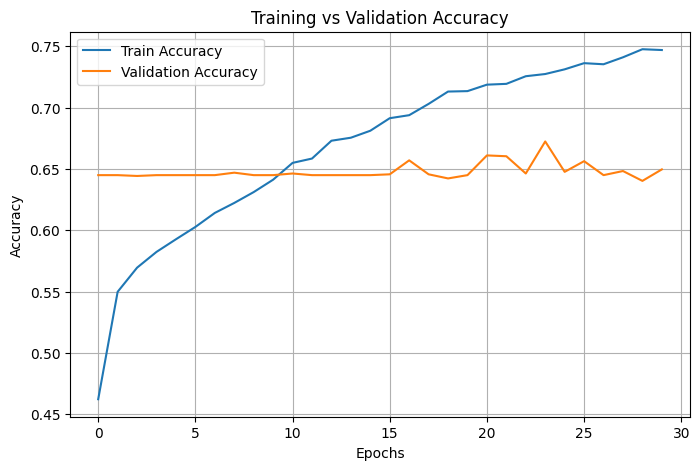

In [ ]:
#Accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

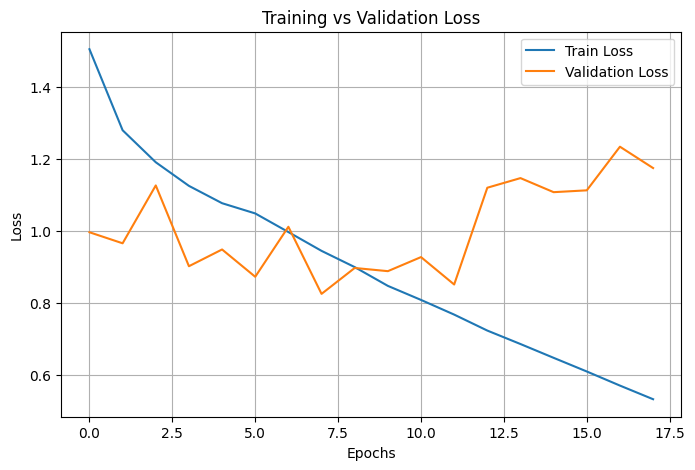

In [ ]:
# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# **8- Import Best Model**

#### **Load The best model**

In [ ]:
from tensorflow.keras.models import load_model
from google.colab import drive

drive.mount('/content/drive')

model = load_model("/content/drive/MyDrive/Best_Model_DlMid.keras")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 ## **Model's Summary**
 provides a detailed of the model architecture, including the types of layers, their output shapes, and the total number of trainable parameters.

In [ ]:
model.summary()

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_486 (Conv2D)             │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_486         │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_162 (Activation)     │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_486 (Dropout)           │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_324               │ (None, 32, 32, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_487 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_487         │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_163 (Activation)     │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_487 (Dropout)           │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_325               │ (None, 16, 16, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_488 (Conv2D)             │ (None, 16, 16, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_488         │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_488 (Dropout)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_489 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_489         │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_489 (Dropout)           │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_326               │ (None, 8, 8, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_490 (Conv2D)             │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_490         │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_490 (Dropout)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_491 (Conv2D)             │ (None, 8, 8, 64)       │       102,46

 Total params: 1,598,219 (6.10 MB)

 Trainable params: 532,547 (2.03 MB)

 Non-trainable params: 576 (2.25 KB)

 Optimizer params: 1,065,096 (4.06 MB)

In [ ]:
optimizer_config = model.optimizer.get_config()
print(optimizer_config)

{'name': 'adamw', 'learning_rate': 0.0005000000237487257, 'weight_decay': 1e-05, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


## **Test Accurecy**

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {100*test_accuracy:.4f}")

Test accuracy: 71.0212


## **Confusion Matrix**

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


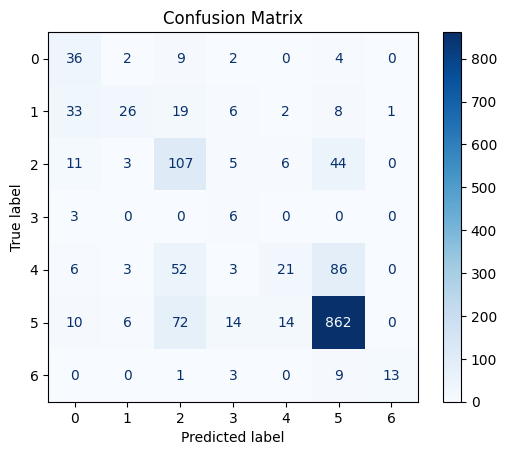

In [ ]:
#Predict on test
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# display confuison matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

## **Classification Report**
display for each class precision, recall and f1-score

In [ ]:
classes = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

report = classification_report(y_true, y_pred, target_names=classes, digits=3)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

       akiec      0.364     0.679     0.474        53
         bcc      0.650     0.274     0.385        95
         bkl      0.412     0.608     0.491       176
          df      0.154     0.667     0.250         9
         mel      0.488     0.123     0.196       171
          nv      0.851     0.881     0.866       978
        vasc      0.929     0.500     0.650        26

    accuracy                          0.710      1508
   macro avg      0.550     0.533     0.473      1508
weighted avg      0.726     0.710     0.695      1508



# **Outout (Predict)**
use the trained model to predict a random test image. The image is displayed with its true label, and the model outputs the predicted class along with the confidence scores for all possible classes.

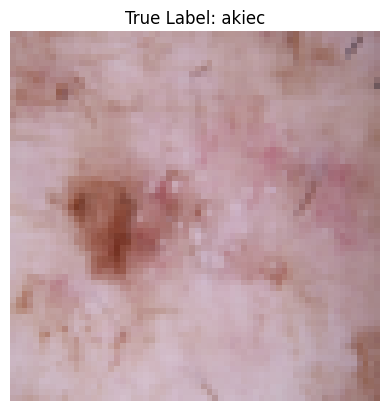

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step
Probabilities:
akiec: 0.3432
bcc: 0.0574
bkl: 0.2781
df: 0.0890
mel: 0.1466
nv: 0.0849
vasc: 0.0008

Predicted Class: akiec (confidence = 0.34)


In [ ]:
# take random photo from test ( new one the model did not see)
idx = np.random.randint(0, len(X_test))
sample_img = X_test[idx]
true_label = np.argmax(y_test[idx])

plt.imshow(sample_img)
# display the true label
plt.title(f"True Label: {classes[true_label]}")
plt.axis("off")
plt.show()

#predict
pred_probs = model.predict(np.expand_dims(sample_img, axis=0))
pred_label = np.argmax(pred_probs)

# see the probabilities for each class
print("Probabilities:")
for label, prob in zip(classes, pred_probs[0]):
    print(f"{label}: {prob:.4f}")

#based on propabilty the model will take highest value and predict based on it
print(f"\nPredicted Class: {classes[pred_label]} (confidence = {pred_probs[0][pred_label]:.2f})")